In [78]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [79]:
from src.data.api_client import APIClientFactory
from src.data.data_validator import DataValidator

In [80]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns 

## Before Feature Engineering

In [81]:
client = APIClientFactory.get_primary_client()
validator = DataValidator()

In [82]:
historical_aqi = client.fetch_historical("Lahore", 31.558, 74.351, "2026-07-20", "2026-07-25")

2026-07-26 20:53:44 | INFO     | OpenMeteoClient:79 | Fetching historical data from https://air-quality-api.open-meteo.com/v1/air-quality for Lahore [2026-07-20 -> 2026-07-25]


In [83]:
type(historical_aqi)

list

In [84]:
df_aqi = pd.DataFrame(historical_aqi)

In [85]:
df_aqi.head()

,date,city,lat,lon,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,uv_index,uv_index_clear_sky,aerosol_optical_depth,european_aqi
0,2026-07-20 00:00:00+05:00,Lahore,31.558,74.351,158.300003,91.699997,680.0,34.000000,11.6,45.0,129.0,0.0,0.0,1.05,113.241653
1,2026-07-20 01:00:00+05:00,Lahore,31.558,74.351,155.500000,92.699997,679.0,31.200001,11.3,46.0,122.0,0.0,0.0,1.08,113.093330
2,2026-07-20 02:00:00+05:00,Lahore,31.558,74.351,167.600006,97.800003,660.0,28.200001,11.2,48.0,129.0,0.0,0.0,1.08,113.000000
3,2026-07-20 03:00:00+05:00,Lahore,31.558,74.351,156.500000,94.300003,602.0,25.000000,11.7,51.0,147.0,0.0,0.0,1.03,113.348328
4,2026-07-20 04:00:00+05:00,Lahore,31.558,74.351,169.500000,93.400002,525.0,21.500000,12.6,55.0,179.0,0.0,0.0,1.04,113.689995


In [67]:
df_data = df_aqi.copy()

In [68]:
df_data.head()

,date,city,lat,lon,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,uv_index,uv_index_clear_sky,aerosol_optical_depth,european_aqi
0,2026-07-20 00:00:00+05:00,Lahore,31.558,74.351,158.300003,91.699997,680.0,34.000000,11.6,45.0,129.0,0.0,0.0,1.05,113.241653
1,2026-07-20 01:00:00+05:00,Lahore,31.558,74.351,155.500000,92.699997,679.0,31.200001,11.3,46.0,122.0,0.0,0.0,1.08,113.093330
2,2026-07-20 02:00:00+05:00,Lahore,31.558,74.351,167.600006,97.800003,660.0,28.200001,11.2,48.0,129.0,0.0,0.0,1.08,113.000000
3,2026-07-20 03:00:00+05:00,Lahore,31.558,74.351,156.500000,94.300003,602.0,25.000000,11.7,51.0,147.0,0.0,0.0,1.03,113.348328
4,2026-07-20 04:00:00+05:00,Lahore,31.558,74.351,169.500000,93.400002,525.0,21.500000,12.6,55.0,179.0,0.0,0.0,1.04,113.689995


In [69]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype                       
---  ------                 --------------  -----                       
 0   date                   144 non-null    datetime64[ns, Asia/Karachi]
 1   city                   144 non-null    object                      
 2   lat                    144 non-null    float64                     
 3   lon                    144 non-null    float64                     
 4   pm10                   144 non-null    float64                     
 5   pm2_5                  144 non-null    float64                     
 6   carbon_monoxide        144 non-null    float64                     
 7   nitrogen_dioxide       144 non-null    float64                     
 8   sulphur_dioxide        144 non-null    float64                     
 9   ozone                  144 non-null    float64                     
 10  dust          

In [70]:
df_data.describe()

,lat,lon,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,uv_index,uv_index_clear_sky,aerosol_optical_depth,european_aqi
count,144.000,144.000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000
mean,31.558,74.351,60.119445,39.950695,540.277778,21.786111,8.836111,84.430556,39.854167,1.178472,2.084375,0.932153,76.792057
std,0.000,0.000,63.254859,24.854891,182.040972,12.656564,2.612573,39.895432,81.518025,1.818280,2.915707,0.334591,21.784196
min,31.558,74.351,11.400000,9.300000,263.000000,3.900000,2.800000,19.000000,0.000000,0.000000,0.000000,0.470000,45.883339
25%,31.558,74.351,23.275000,21.975000,422.000000,13.200000,7.300000,55.000000,0.000000,0.000000,0.000000,0.660000,63.015831
50%,31.558,74.351,40.049999,33.000000,484.500000,19.500000,8.400000,73.000000,1.000000,0.100000,0.150000,0.865000,67.222118
75%,31.558,74.351,61.200000,47.550000,616.000000,28.050000,9.825000,115.000000,38.250000,1.762500,4.100000,1.110000,87.312080
max,31.558,74.351,323.200012,119.000000,1186.000000,70.400002,17.500000,182.000000,392.000000,7.400000,9.400000,2.230000,122.641678


In [71]:
null_counts = df_data.isnull().sum()
null_pct = (null_counts / len(df_data) * 100).round(2)
missing_report = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct})
missing_report = missing_report[missing_report["null_count"] > 0].sort_values("null_pct", ascending=False)
missing_report

,null_count,null_pct


In [72]:
# --- Skew + suggested imputation strategy, numeric columns only ---
numeric_cols = df_data.select_dtypes(include="number").columns

skew_report = pd.DataFrame({
    "skew": df_data[numeric_cols].skew(),
    "mean": df_data[numeric_cols].mean(),
    "median": df_data[numeric_cols].median(),
})

def suggest_strategy(skew):
    if abs(skew) < 0.5:
        return "mean"       # roughly symmetric
    else:
        return "median"     # skewed — mean gets pulled by outliers/tail
skew_report["suggested_strategy"] = skew_report["skew"].apply(suggest_strategy)
skew_report

,skew,mean,median,suggested_strategy
lat,0.000000,31.558000,31.558000,mean
lon,0.000000,74.351000,74.351000,mean
pm10,2.301506,60.119445,40.049999,median
pm2_5,1.287959,39.950695,33.000000,median
carbon_monoxide,1.557062,540.277778,484.500000,median
nitrogen_dioxide,1.410909,21.786111,19.500000,median
sulphur_dioxide,0.905979,8.836111,8.400000,median
ozone,0.656401,84.430556,73.000000,median
dust,2.527829,39.854167,1.000000,median
uv_index,1.708517,1.178472,0.100000,median


In [61]:
df = df_data.loc[:, "pm10":]

In [62]:
corr = df.corr()
corr.style.background_gradient(cmap='coolwarm')

,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,uv_index,uv_index_clear_sky,aerosol_optical_depth,european_aqi
pm10,1.000000,0.927117,0.045810,-0.015673,0.756576,0.223462,0.973511,-0.079745,-0.058676,0.586289,0.818928
pm2_5,0.927117,1.000000,0.259306,0.254984,0.756263,0.062834,0.827001,-0.229284,-0.243316,0.627227,0.733383
carbon_monoxide,0.045810,0.259306,1.000000,0.779437,0.199630,-0.382488,-0.084964,-0.361270,-0.391050,-0.029115,-0.127875
nitrogen_dioxide,-0.015673,0.254984,0.779437,1.000000,0.135634,-0.708327,-0.175065,-0.553377,-0.570674,0.054379,-0.130768
sulphur_dioxide,0.756576,0.756263,0.199630,0.135634,1.000000,0.157389,0.702429,0.150804,0.103572,0.335751,0.576131
ozone,0.223462,0.062834,-0.382488,-0.708327,0.157389,1.000000,0.297875,0.608692,0.593791,0.190667,0.185806
dust,0.973511,0.827001,-0.084964,-0.175065,0.702429,0.297875,1.000000,0.000592,0.039991,0.525679,0.822594
uv_index,-0.079745,-0.229284,-0.361270,-0.553377,0.150804,0.608692,0.000592,1.000000,0.898802,-0.246974,-0.084979
uv_index_clear_sky,-0.058676,-0.243316,-0.391050,-0.570674,0.103572,0.593791,0.039991,0.898802,1.000000,-0.188659,-0.083643
aerosol_optical_depth,0.586289,0.627227,-0.029115,0.054379,0.335751,0.190667,0.525679,-0.246974,-0.188659,1.000000,0.498125


<Axes: >

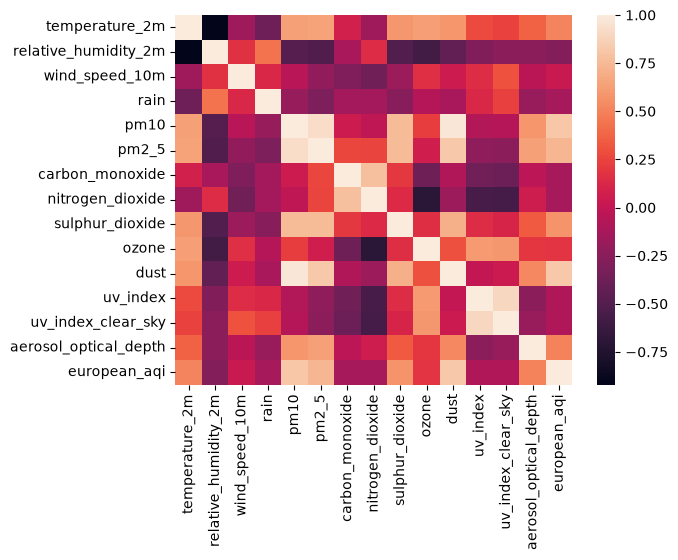

In [44]:
sns.heatmap(corr)

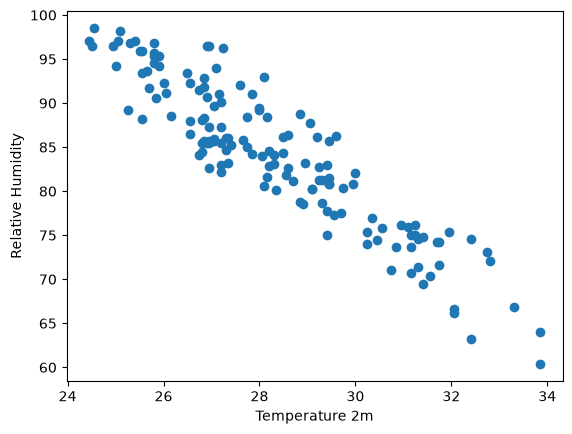

In [47]:
plt.scatter(df['temperature_2m'], df["relative_humidity_2m"])
plt.xlabel("Temperature 2m")
plt.ylabel("Relative Humidity")
plt.show()